# Cargando Biblotecas

In [3]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

# Función Para ajustar

la ley de hooke es dada por una ecuación lineal:

$F=-kx$

donde:
- \( F \) es la fuerza aplicada,
- \( k \) es la constante elástica del resorte,
- \( x \) es la elongación.

Podemos usar el método de mínimos cuadrados (https://es.wikipedia.org/wiki/M%C3%ADnimos_cuadrados) para encontrar el valor de \( k \) ajustando una línea recta a los datos experimentales.

Para lo anterior necesitamos definir una función error ($\xi$) (https://es.wikipedia.org/wiki/Prueba_%CF%87%C2%B2_de_Pearson) que será el método 
de minimos cuadrado minimize:

$\xi=\sum_{i=0}^{i=n} \frac{dato_i - model_i}{error_i}$

Para esa función se necesita un vector error, en general tomamos 0.5 cm, eso depende
de la resolucióon de la imagen.

In [1]:
def fitfunc (p, x):
    return p[0] + p[1] * x

def errfunc (params, x, y, err):
 return  (y - fitfunc(params, x)) / err    

# Cargando Datos

Se puede colocar los datos para cada resorte en archivo
de texto en dos columnas:

    # x   F
    0.1   2
    0.2   4
    0.3   6
    0.4   8
    0.5   10

Observa que la enlogación, $x$, debe ir en metros. La Fuerza
se puede calcular multiplicando la masa deL  peso (**pasar gramos a kilogramos**) por la constante
de la gravedad ($g=9.81\,m/s^{2}$)


Tambien se puede crear los vectores a mano, por ejemplo 

`xdata = [0.1,0.2,0.3,0.4,0.5] `

`ydata = [2,4,6,8,10] `

Se necesita un vector error. Como ese error proviene del calculo
de la fuerza, podemo asumir q el error en el peso son 5 gr, $F=mg$, 
$F_e=0.005*9.81\approx 0.05$,

`yerr  = [0.05, 0.05, 0.05, 0.05, 0.05]`

In [13]:
#datos generados, k = 50 # N/m

xdata, ydata = np.loadtxt('ley_hooke.txt', unpack=True)
yerr  = [0.05]*len(xdata)

## Graficando los datos

Text(0, 0.5, 'Fuerza (N)')

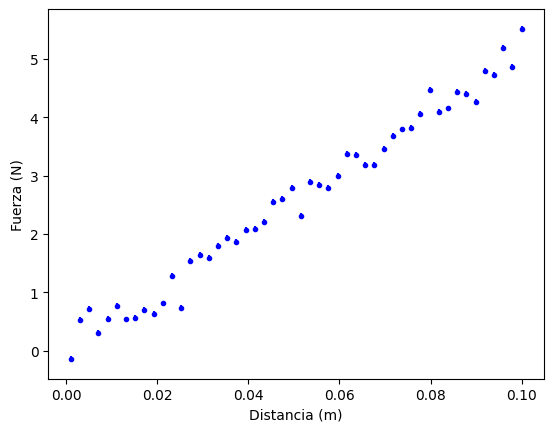

In [15]:
plt.errorbar(xdata, ydata, yerr=yerr, fmt='b.')

plt.xlabel('Distancia (m)')
plt.ylabel('Fuerza (N)')

## Ajustando los Datos

In [20]:
# Parametros Iniciales
v_inic = [1.0, 1.0]

# Funcion de Minimos Cuadrados
out = optimize.leastsq(errfunc, v_inic,
                       args=(xdata, ydata, yerr), full_output=1)

# Resultados
pfinal = out[0]
covar = out[1]


# Grados de Libertad
degfree = len(xdata)  - len(v_inic)

# Chi Cuadrado reducido
s_sq = (errfunc(pfinal,xdata, ydata, yerr)**2).sum()/degfree
print ("Chi^2_reducido: {:.2f}".format(s_sq))

pcov = covar * s_sq
perr = np.sqrt(np.diag(covar))

# Valor de los Parametros Ajustados
print ("x_0 = {:.2f} +- {:.2f} m".format(pfinal[0], perr[0]))
print ("k = {:.2f} +- {:.2f} N/m ".format(pfinal[1], perr[1]))

Chi^2_reducido: 18.17
x_0 = -0.01 +- 0.01 m
k = 51.33 +- 0.24 N/m 


## Graficando el Ajuste

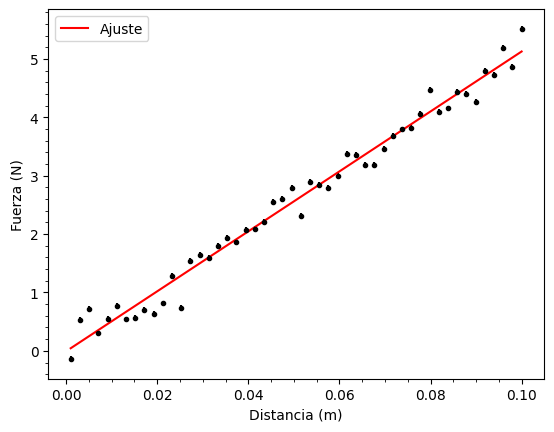

In [17]:
plt.errorbar(xdata, ydata, yerr=yerr, fmt='k.')

plt.plot(xdata, fitfunc(pfinal, xdata), 'r-', label='Ajuste')

plt.xlabel('Distancia (m)')
plt.ylabel('Fuerza (N)')
plt.legend()
plt.minorticks_on()
plt.savefig('Ajuste_ley_Hooke.png')